In [1]:
from pathlib import Path
import csv
import json
import re
import pandas as pd
import numpy as np

# Folder with manual annotation exports
DATA_DIR = Path(r"C:\data\manualFights")
MAX_LEGIT_FILESIZE_BYTES = 20 * 1024
PARSE_CANDIDATE_MAX_BYTES = 10 * 1024
VALID_VIDEO_IDS = {"g1", "g2", "g3"}

all_files = sorted([p for p in DATA_DIR.iterdir() if p.is_file()])
all_candidate_files = [p for p in all_files if p.stat().st_size < PARSE_CANDIDATE_MAX_BYTES]

if not all_files:
    raise FileNotFoundError(f"No files found in {DATA_DIR}")
if not all_candidate_files:
    raise FileNotFoundError(f"No files under {PARSE_CANDIDATE_MAX_BYTES} bytes found in {DATA_DIR}")

print(f"Found {len(all_files)} total files in {DATA_DIR}")
print(f"Attempting to parse {len(all_candidate_files)} files under {PARSE_CANDIDATE_MAX_BYTES} bytes (any extension)")

Found 25 total files in C:\data\manualFights
Attempting to parse 23 files under 10240 bytes (any extension)


In [2]:
def normalize_video_id(text: str):
    if text is None:
        return None
    lower = str(text).lower()

    # Match g1/g2/g3 or gt1/gt2/gt3 even when surrounded by underscores or punctuation
    match = re.search(r"(?<![a-z0-9])gt?([123])(?![a-z0-9])", lower)
    if match:
        return f"g{match.group(1)}"
    return None


def extract_user_from_filename(stem: str) -> str:
    marker = "_assignsubmission_file_"
    if marker in stem:
        return stem.split(marker, 1)[0].strip()
    return stem


def parse_temporal_coordinates(value):
    """Parse temporal field like '[12.3]' or '[12.3,13.7]' into start/end/point."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.nan, np.nan, np.nan

    # Handle list/tuple directly (e.g., JSON z=[start,end])
    if isinstance(value, (list, tuple)):
        vals = [float(v) for v in value if v is not None]
        if len(vals) == 0:
            return np.nan, np.nan, np.nan
        if len(vals) == 1:
            return np.nan, np.nan, vals[0]
        start, end = vals[0], vals[1]
        return start, end, (start + end) / 2

    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(value))
    if not nums:
        return np.nan, np.nan, np.nan

    values = [float(n) for n in nums]
    if len(values) == 1:
        point = values[0]
        return np.nan, np.nan, point

    start = values[0]
    end = values[1]
    point = (start + end) / 2
    return start, end, point


def parse_via_json_rows(payload: dict) -> pd.DataFrame:
    file_map = payload.get("file", {}) if isinstance(payload, dict) else {}
    metadata_map = payload.get("metadata", {}) if isinstance(payload, dict) else {}

    if not isinstance(metadata_map, dict) or len(metadata_map) == 0:
        return pd.DataFrame()

    rows = []
    for metadata_id, item in metadata_map.items():
        if not isinstance(item, dict):
            continue

        vid = str(item.get("vid", ""))
        file_info = file_map.get(vid, {}) if isinstance(file_map, dict) else {}
        file_name = file_info.get("fname", "") if isinstance(file_info, dict) else ""

        av = item.get("av", {})
        if isinstance(av, dict):
            label = " | ".join([str(v) for v in av.values() if v is not None]).strip()
        else:
            label = str(av)

        rows.append(
            {
                "metadata_id": metadata_id,
                "file_list": file_name,
                "flags": item.get("flg", np.nan),
                "temporal_coordinates": item.get("z", []),
                "spatial_coordinates": item.get("xy", []),
                "metadata": label,
            }
        )

    return pd.DataFrame(rows)


def parse_one_annotation_file(file_path: Path):
    size_bytes = file_path.stat().st_size
    size_ok = size_bytes <= MAX_LEGIT_FILESIZE_BYTES

    file_stem = file_path.stem
    user_label = extract_user_from_filename(file_stem)

    # Primary hint from filename
    video_id = normalize_video_id(file_stem)

    df = pd.DataFrame()
    source_format = "unknown"

    # Try JSON first for .json files or JSON-looking content (even without extension)
    raw_text = file_path.read_text(encoding="utf-8", errors="ignore")
    stripped = raw_text.lstrip()
    looks_like_json = file_path.suffix.lower() == ".json" or stripped.startswith("{")

    if looks_like_json:
        try:
            payload = json.loads(raw_text)
            df = parse_via_json_rows(payload)
            source_format = "via_json"
        except Exception:
            df = pd.DataFrame()

    # Fallback to CSV parser when JSON path didn't yield rows
    if df.empty:
        try:
            df = pd.read_csv(
                file_path,
                comment="#",
                header=None,
                names=[
                    "metadata_id",
                    "file_list",
                    "flags",
                    "temporal_coordinates",
                    "spatial_coordinates",
                    "metadata",
                ],
                dtype=str,
                encoding="utf-8",
                engine="python",
                on_bad_lines="skip",
            )
            source_format = "via_csv"
        except Exception as exc:
            return {
                "status": f"error: {exc}",
                "file": file_path.name,
                "size_bytes": size_bytes,
                "size_ok": size_ok,
                "user": user_label,
                "video_id": video_id,
                "events": pd.DataFrame(),
            }

    df = df.dropna(axis=0, how="all")
    if df.empty:
        return {
            "status": "no_rows_after_parse",
            "file": file_path.name,
            "size_bytes": size_bytes,
            "size_ok": size_ok,
            "user": user_label,
            "video_id": video_id,
            "events": pd.DataFrame(),
        }

    # Infer video id from file_list column when available (e.g. ["gt2.mp4"] / gt2.mp4)
    if "file_list" in df.columns and df["file_list"].notna().any():
        inferred = normalize_video_id(" ".join(df["file_list"].dropna().astype(str).tolist()))
        if inferred is not None:
            video_id = inferred

    # Parse timing info from temporal_coordinates
    timing = df["temporal_coordinates"].apply(parse_temporal_coordinates)
    timing_df = pd.DataFrame(timing.tolist(), columns=["time_start", "time_end", "time_point"])

    events = df.copy()
    events = pd.concat([events, timing_df], axis=1)
    events["duration"] = events["time_end"] - events["time_start"]

    # Parse event label from metadata text, keep raw if parsing fails
    events["event_label"] = (
        events["metadata"]
        .astype(str)
        .str.replace(r"[{}\"]", "", regex=True)
        .str.replace(r"\b\d+\s*:\s*", "", regex=True)
        .str.strip()
    )

    # Keep rows that contain at least some timing info
    events = events[
        events[["time_start", "time_end", "time_point"]].notna().any(axis=1)
    ].copy()

    if events.empty:
        status = "table_found_but_no_timing_rows"
    else:
        status = "ok"

    events.insert(0, "source_file", file_path.name)
    events.insert(1, "user", user_label)
    events.insert(2, "video_id", video_id)
    events.insert(3, "file_size_bytes", size_bytes)
    events.insert(4, "size_ok", size_ok)
    events.insert(5, "source_format", source_format)
    events["event_index"] = np.arange(1, len(events) + 1)

    # Helpful normalization for downstream filtering
    events["video_id"] = events["video_id"].where(events["video_id"].isin(VALID_VIDEO_IDS), events["video_id"])

    return {
        "status": status,
        "file": file_path.name,
        "size_bytes": size_bytes,
        "size_ok": size_ok,
        "user": user_label,
        "video_id": video_id,
        "events": events,
    }

In [6]:
parsed = []
for file_path in all_candidate_files:
    try:
        parsed.append(parse_one_annotation_file(file_path))
    except Exception as exc:
        parsed.append(
            {
                "status": f"error: {exc}",
                "file": file_path.name,
                "size_bytes": file_path.stat().st_size,
                "size_ok": file_path.stat().st_size <= MAX_LEGIT_FILESIZE_BYTES,
                "user": extract_user_from_filename(file_path.stem),
                "video_id": normalize_video_id(file_path.stem),
                "events": pd.DataFrame(),
            }
        )

file_report = pd.DataFrame(
    [
        {
            "file": p["file"],
            "user": p["user"],
            "video_id": p["video_id"],
            "size_bytes": p["size_bytes"],
            "size_kb": round(p["size_bytes"] / 1024, 2),
            "size_ok": p["size_ok"],
            "status": p["status"],
            "n_events": len(p["events"]),
        }
        for p in parsed
    ]
)

all_events = [p["events"] for p in parsed if not p["events"].empty]
if all_events:
    events_df = pd.concat(all_events, ignore_index=True)
else:
    events_df = pd.DataFrame()

# Convenience filter: files that look legit and have a recognized video id
clean_events_df = events_df.copy()
if not clean_events_df.empty:
    clean_events_df = clean_events_df[
        clean_events_df["size_ok"]
        & clean_events_df["video_id"].isin(VALID_VIDEO_IDS)
    ].copy()

print("=== File quality report (only parsed candidates <10KB) ===")
display(file_report.sort_values(["size_ok", "status", "n_events", "file"], ascending=[False, True, False, True]))

print("\n=== Parsed events (all parsed candidates) ===")
display(events_df.head(20))

print("\n=== Parsed events (clean subset: <=20KB and g1/g2/g3) ===")
display(clean_events_df.head(20))

=== File quality report (only parsed candidates <10KB) ===


,file,user,video_id,size_bytes,size_kb,size_ok,status,n_events
0,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,6.37,True,ok,69
17,Samir Dupraz_3276632_assignsubmission_file_gt3...,Samir Dupraz_3276632,g3,6995,6.83,True,ok,60
21,Xulia Maillot Rodriguez_3276638_assignsubmissi...,Xulia Maillot Rodriguez_3276638,g2,5414,5.29,True,ok,56
4,Elodie Pulfer_3276647_assignsubmission_file_gt...,Elodie Pulfer_3276647,g3,4565,4.46,True,ok,47
5,Emmanuelle Tran_3276630_assignsubmission_file_...,Emmanuelle Tran_3276630,g1,4349,4.25,True,ok,44
2,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,4125,4.03,True,ok,39
15,Maélie Collin_3276642_assignsubmission_file_gt...,Maélie Collin_3276642,g1,3909,3.82,True,ok,38
3,Anna Dundas Foerster_3276631_assignsubmission_...,Anna Dundas Foerster_3276631,g2,3858,3.77,True,ok,36
11,Léo Currat_3276622_assignsubmission_file_gt1_C...,Léo Currat_3276622,g1,3594,3.51,True,ok,35
12,Martin Gumy_3276620_assignsubmission_file_gt1_...,Martin Gumy_3276620,g1,3595,3.51,True,ok,35



=== Parsed events (all parsed candidates) ===


,source_file,user,video_id,file_size_bytes,size_ok,source_format,metadata_id,file_list,flags,temporal_coordinates,spatial_coordinates,metadata,time_start,time_end,time_point,duration,event_label,event_index
0,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_m208utEc,"[""gt3.mp4""]",0,"[6.676,7.676]",[],"{""1"":""fight events""}",6.676,7.676,7.176,1.0,fight events,1
1,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_zuXKjhXc,"[""gt3.mp4""]",0,"[8.399,9.399]",[],"{""1"":""fight events""}",8.399,9.399,8.899,1.0,fight events,2
2,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_P3IbbPl5,"[""gt3.mp4""]",0,"[9.252,10.252]",[],"{""1"":""fight events""}",9.252,10.252,9.752,1.0,fight events,3
3,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_a6JOPjZS,"[""gt3.mp4""]",0,"[6.683,7.683]",[],"{""1"":""fight events""}",6.683,7.683,7.183,1.0,fight events,4
4,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_KdjFIa6A,"[""gt3.mp4""]",0,"[8.878,9.878]",[],"{""1"":""fight events""}",8.878,9.878,9.378,1.0,fight events,5
5,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_X0kquLR6,"[""gt3.mp4""]",0,"[1.834,2.834]",[],"{""1"":""fight events""}",1.834,2.834,2.334,1.0,fight events,6
6,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_hkjb64MM,"[""gt3.mp4""]",0,"[6.398,7.398]",[],"{""1"":""fight events""}",6.398,7.398,6.898,1.0,fight events,7
7,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_9Xd3d4FV,"[""gt3.mp4""]",0,"[8.166,9.166]",[],"{""1"":""fight events""}",8.166,9.166,8.666,1.0,fight events,8
8,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_XJYX1nX9,"[""gt3.mp4""]",0,"[8.91,9.91]",[],"{""1"":""fight events""}",8.910,9.910,9.410,1.0,fight events,9
9,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_a5iOxVwv,"[""gt3.mp4""]",0,"[10.631,11.631]",[],"{""1"":""fight events""}",10.631,11.631,11.131,1.0,fight events,10



=== Parsed events (clean subset: <=20KB and g1/g2/g3) ===


,source_file,user,video_id,file_size_bytes,size_ok,source_format,metadata_id,file_list,flags,temporal_coordinates,spatial_coordinates,metadata,time_start,time_end,time_point,duration,event_label,event_index
0,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_m208utEc,"[""gt3.mp4""]",0,"[6.676,7.676]",[],"{""1"":""fight events""}",6.676,7.676,7.176,1.0,fight events,1
1,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_zuXKjhXc,"[""gt3.mp4""]",0,"[8.399,9.399]",[],"{""1"":""fight events""}",8.399,9.399,8.899,1.0,fight events,2
2,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_P3IbbPl5,"[""gt3.mp4""]",0,"[9.252,10.252]",[],"{""1"":""fight events""}",9.252,10.252,9.752,1.0,fight events,3
3,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_a6JOPjZS,"[""gt3.mp4""]",0,"[6.683,7.683]",[],"{""1"":""fight events""}",6.683,7.683,7.183,1.0,fight events,4
4,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_KdjFIa6A,"[""gt3.mp4""]",0,"[8.878,9.878]",[],"{""1"":""fight events""}",8.878,9.878,9.378,1.0,fight events,5
5,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_X0kquLR6,"[""gt3.mp4""]",0,"[1.834,2.834]",[],"{""1"":""fight events""}",1.834,2.834,2.334,1.0,fight events,6
6,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_hkjb64MM,"[""gt3.mp4""]",0,"[6.398,7.398]",[],"{""1"":""fight events""}",6.398,7.398,6.898,1.0,fight events,7
7,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_9Xd3d4FV,"[""gt3.mp4""]",0,"[8.166,9.166]",[],"{""1"":""fight events""}",8.166,9.166,8.666,1.0,fight events,8
8,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_XJYX1nX9,"[""gt3.mp4""]",0,"[8.91,9.91]",[],"{""1"":""fight events""}",8.910,9.910,9.410,1.0,fight events,9
9,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6527,True,via_csv,1_a5iOxVwv,"[""gt3.mp4""]",0,"[10.631,11.631]",[],"{""1"":""fight events""}",10.631,11.631,11.131,1.0,fight events,10


In [7]:
if clean_events_df.empty:
    print("No clean events found yet. Check `file_report` and adjust parsing heuristics if needed.")
else:
    summary_by_user = (
        clean_events_df.groupby(["user", "video_id"], dropna=False)
        .agg(
            n_events=("event_index", "count"),
            first_time=("time_point", "min"),
            last_time=("time_point", "max"),
            mean_duration=("duration", "mean"),
        )
        .reset_index()
        .sort_values(["video_id", "user"])
    )

    print("=== Events summary by user and video ===")
    display(summary_by_user)

    print("\n=== Timing distribution per user (describe) ===")
    timing_stats = (
        clean_events_df.groupby("user")["time_point"]
        .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        .reset_index()
    )
    display(timing_stats)

    # Keep one tidy table focused on event timing fields + user separation
    tidy_cols = [
        "source_file", "user", "video_id", "event_index", "event_label",
        "time_start", "time_end", "time_point", "duration"
    ]
    tidy_events_df = clean_events_df[[c for c in tidy_cols if c in clean_events_df.columns]].copy()

    print("\n=== Tidy events dataframe (ready for exploration) ===")
    display(tidy_events_df.head(50))

    # Example exploratory pivot: event counts by user x video
    user_video_counts = tidy_events_df.pivot_table(
        index="user",
        columns="video_id",
        values="event_index",
        aggfunc="count",
        fill_value=0,
    )
    print("\n=== Event counts matrix (user x video_id) ===")
    display(user_video_counts)

    # Sort by timing for timeline-like inspection
    timeline_view = tidy_events_df.sort_values(["video_id", "user", "time_point", "time_start"], na_position="last")
    print("\n=== Timeline view (sorted) ===")
    display(timeline_view.head(100))

=== Events summary by user and video ===


,user,video_id,n_events,first_time,last_time,mean_duration
2,Amaranthe Vaucher-De-La-Croix_3276627,g1,39,49.097000,280.325000,1.004156
5,Emmanuelle Tran_3276630,g1,44,15.559000,281.064000,1.000000
11,Léo Currat_3276622,g1,35,13.420000,279.957000,0.997229
12,Martin Gumy_3276620,g1,35,101.750000,280.749000,1.000000
13,Matis Pellissier_3276634,g1,33,101.411000,280.955000,1.000000
14,Matteo Roggo_3276639,g1,34,35.705440,280.652000,1.167667
15,Maélie Collin_3276642,g1,38,103.391000,280.514000,0.976716
18,Tess Meyer_3276624,g1,66,111.575000,280.698000,1.000000
21,Zoe St-Louis_3276619,g1,30,111.581815,279.771000,0.656955
1,Amandine Richard_3276618,g2,19,2.092000,218.804050,1.010037



=== Timing distribution per user (describe) ===


,user,count,mean,std,min,10%,25%,50%,75%,90%,max
0,Alexia Sperandio_3276625,69.0,67.524375,77.445614,2.334000,9.403600,20.435000,38.849000,64.176000,239.084000,282.426000
1,Amandine Richard_3276618,19.0,45.109439,62.774134,2.092000,5.669774,12.954500,24.841210,44.120420,83.886370,218.804050
2,Amaranthe Vaucher-De-La-Croix_3276627,39.0,167.824796,61.679913,49.097000,112.185800,125.994500,148.644000,176.352000,269.038200,280.325000
3,Anna Dundas Foerster_3276631,36.0,189.074104,113.822724,1.822000,13.942500,49.699244,216.599067,270.847000,318.197985,343.295460
4,Elodie Pulfer_3276647,47.0,58.536829,72.671930,1.906040,8.377032,17.893540,32.236040,59.362780,181.453920,281.919020
5,Emmanuelle Tran_3276630,44.0,158.029022,67.814748,15.559000,102.178353,116.568000,145.138500,179.857272,268.010000,281.064000
6,Gaston Parmentier_3276645,21.0,38.715333,36.700840,2.493000,13.180000,23.657000,30.669000,46.430000,50.739000,186.376000
7,Hugo Marchant_3276626,17.0,30.091474,14.653724,1.864000,10.273800,23.958000,29.908000,42.797000,48.834200,51.295000
8,Hugo Schick_3276644,11.0,29.306152,17.020929,1.795000,5.567000,18.050238,30.524725,44.145000,47.457000,50.183475
9,Jasper Venezia_3276617,15.0,50.707534,62.468880,1.724000,6.954600,18.227500,31.943000,46.573148,131.657352,212.366840



=== Tidy events dataframe (ready for exploration) ===


,source_file,user,video_id,event_index,event_label,time_start,time_end,time_point,duration
0,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,1,fight events,6.676,7.67600,7.176000,1.00000
1,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,2,fight events,8.399,9.39900,8.899000,1.00000
2,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,3,fight events,9.252,10.25200,9.752000,1.00000
3,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,4,fight events,6.683,7.68300,7.183000,1.00000
4,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,5,fight events,8.878,9.87800,9.378000,1.00000
5,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,6,fight events,1.834,2.83400,2.334000,1.00000
6,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,7,fight events,6.398,7.39800,6.898000,1.00000
7,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,8,fight events,8.166,9.16600,8.666000,1.00000
8,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,9,fight events,8.910,9.91000,9.410000,1.00000
9,Alexia Sperandio_3276625_assignsubmission_file...,Alexia Sperandio_3276625,g3,10,fight events,10.631,11.63100,11.131000,1.00000



=== Event counts matrix (user x video_id) ===


video_id,g1,g2,g3
user,,,
Alexia Sperandio_3276625,0,0,69
Amandine Richard_3276618,0,19,0
Amaranthe Vaucher-De-La-Croix_3276627,39,0,0
Anna Dundas Foerster_3276631,0,36,0
Elodie Pulfer_3276647,0,0,47
Emmanuelle Tran_3276630,44,0,0
Gaston Parmentier_3276645,0,21,0
Hugo Marchant_3276626,0,17,0
Hugo Schick_3276644,0,11,0



=== Timeline view (sorted) ===


,source_file,user,video_id,event_index,event_label,time_start,time_end,time_point,duration
88,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,1,fight event,48.597,49.597,49.097,1.00
89,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,2,fight event,99.104,100.104,99.604,1.00
90,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,3,fight event,102.685,103.685,103.185,1.00
91,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,4,fight event,110.609,111.729,111.169,1.12
92,Amaranthe Vaucher-De-La-Croix_3276627_assignsu...,Amaranthe Vaucher-De-La-Croix_3276627,g1,5,fight event,111.940,112.940,112.440,1.00
...,...,...,...,...,...,...,...,...,...
352,Léo Currat_3276622_assignsubmission_file_gt1_C...,Léo Currat_3276622,g1,13,Fight,138.671,139.671,139.171,1.00
374,Léo Currat_3276622_assignsubmission_file_gt1_C...,Léo Currat_3276622,g1,35,Fight,140.526,141.526,141.026,1.00
353,Léo Currat_3276622_assignsubmission_file_gt1_C...,Léo Currat_3276622,g1,14,Fight,142.764,143.764,143.264,1.00
354,Léo Currat_3276622_assignsubmission_file_gt1_C...,Léo Currat_3276622,g1,15,Fight,143.859,144.859,144.359,1.00


In [8]:
files_with_events_any = int((file_report['n_events'] > 0).sum())
files_with_events_clean = int(file_report.loc[file_report['video_id'].isin(VALID_VIDEO_IDS) & file_report['size_ok'], 'n_events'].gt(0).sum())

print(f"Files with parsed event entries (all parsed <10KB candidates): {files_with_events_any}")
print(f"Files with legit entries (<=20KB and g1/g2/g3): {files_with_events_clean}")

Files with parsed event entries (all parsed <10KB candidates): 23
Files with legit entries (<=20KB and g1/g2/g3): 23


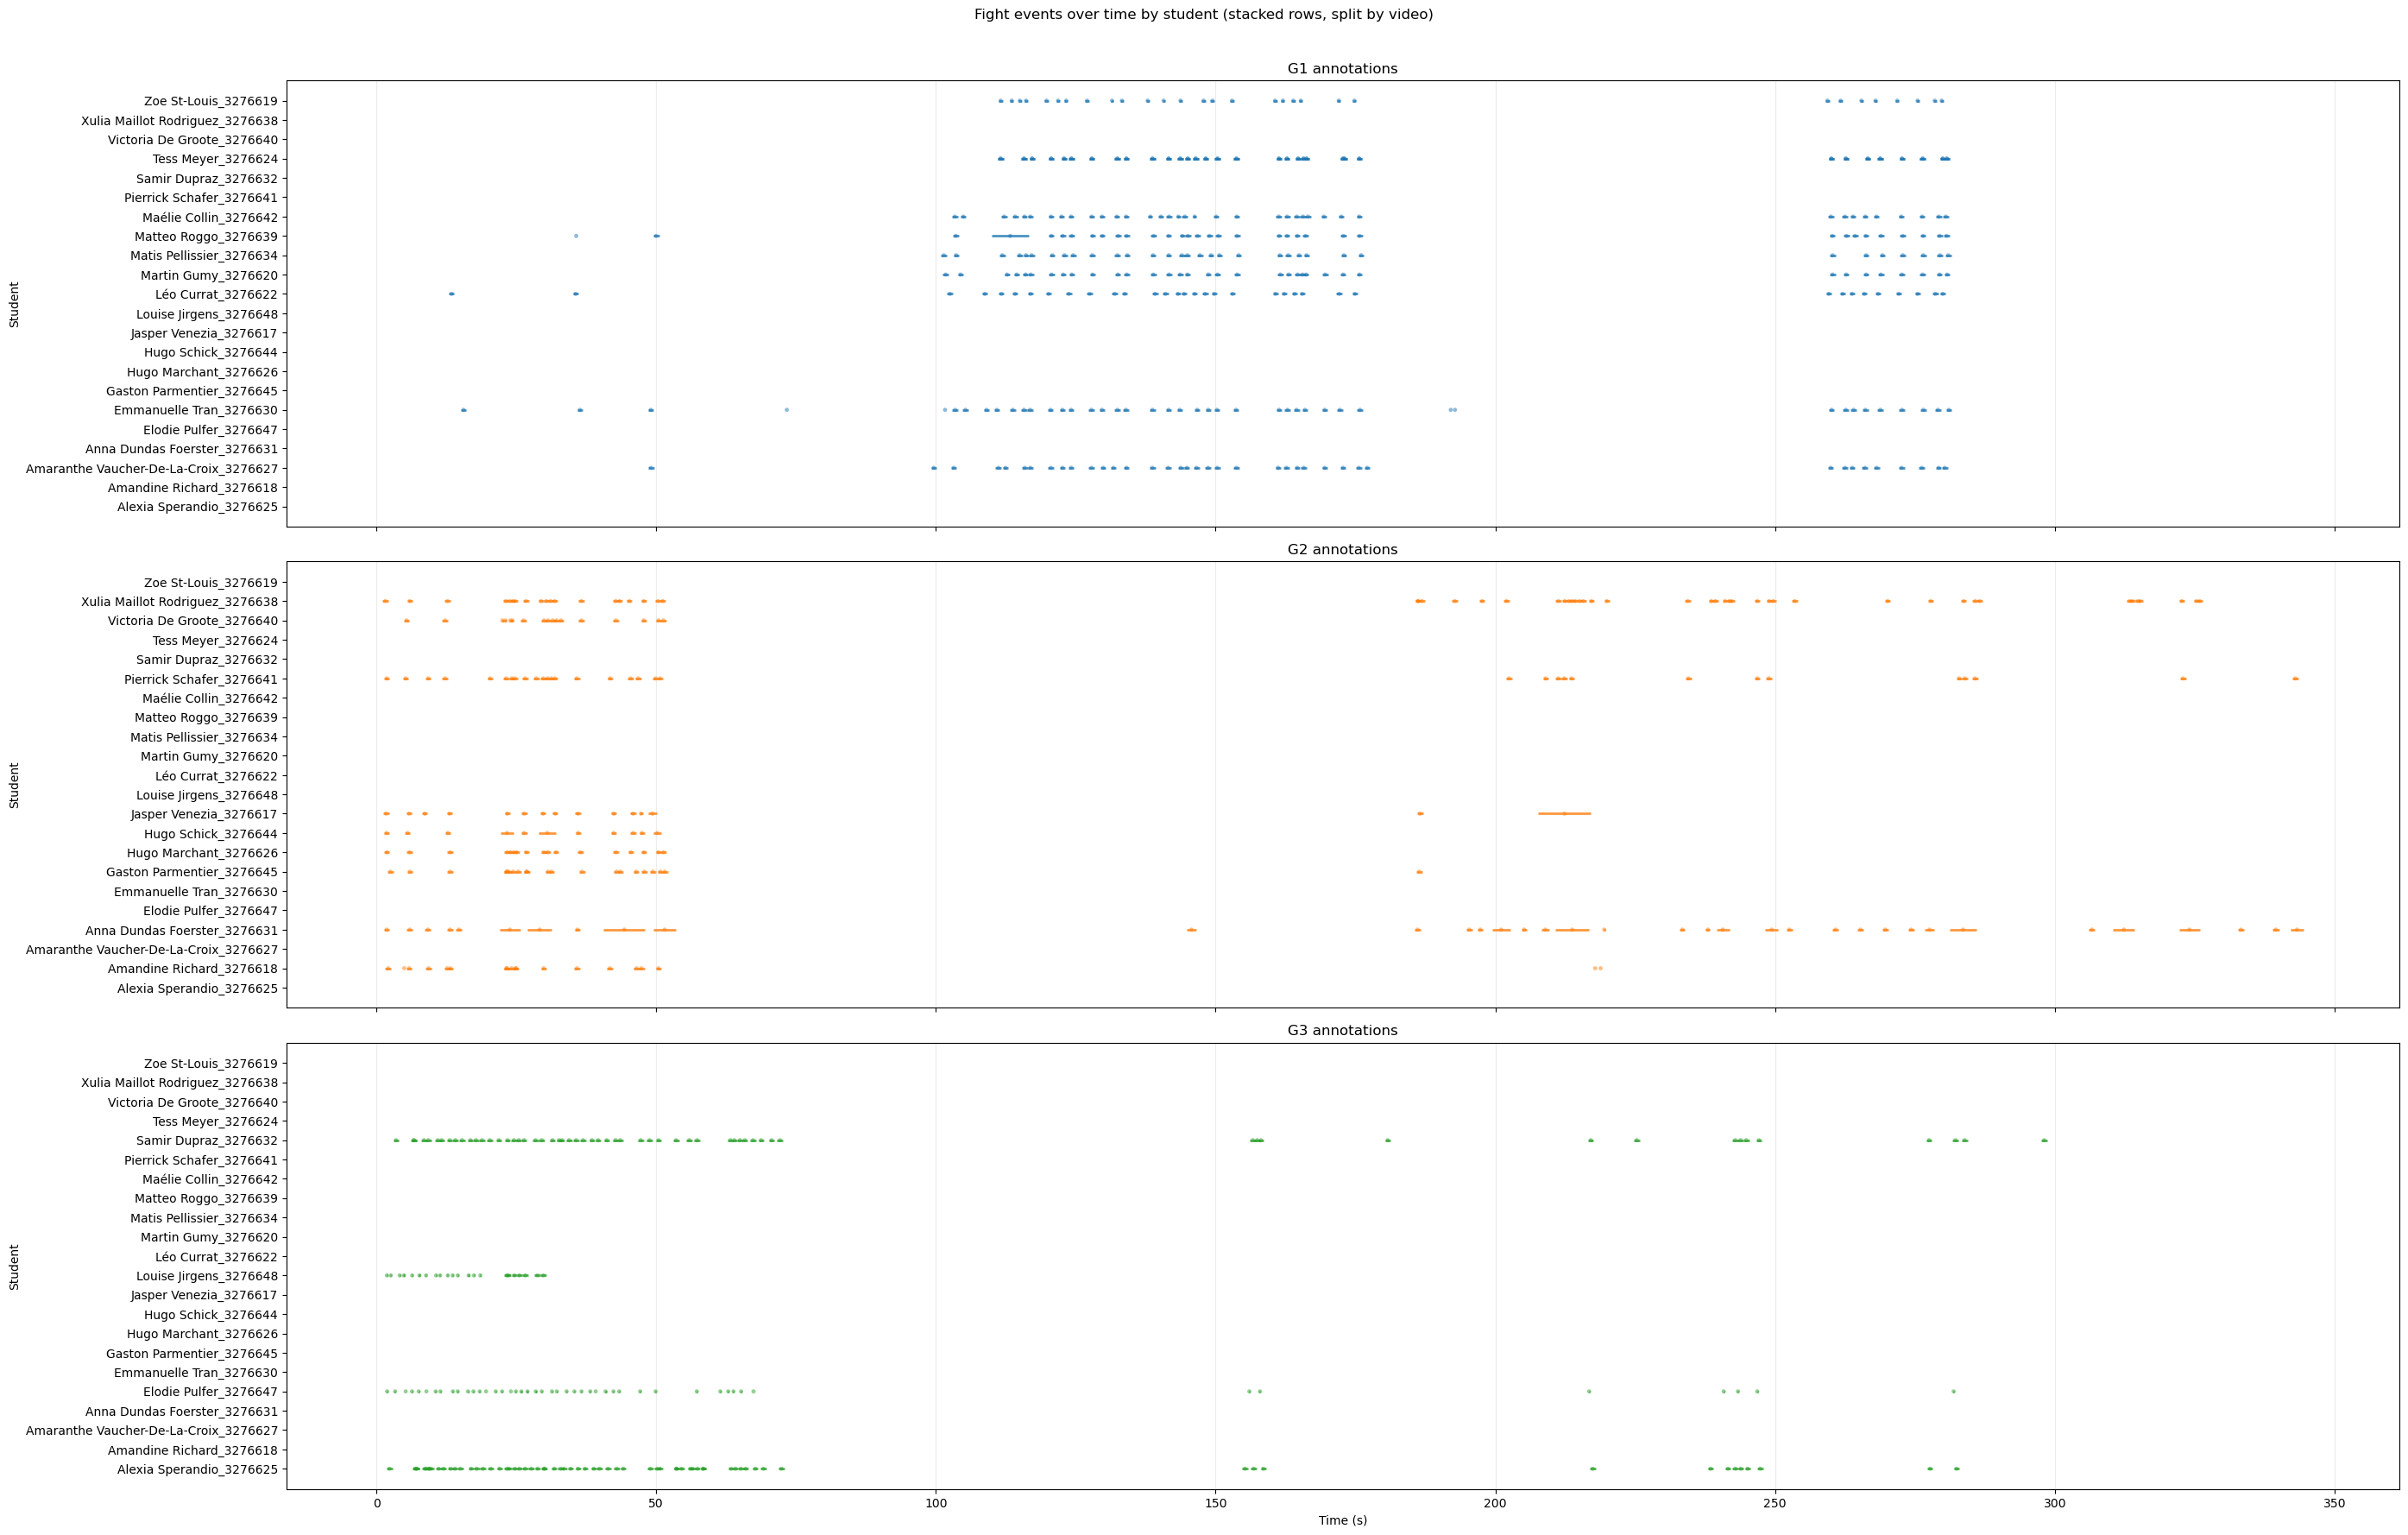

In [9]:
import matplotlib.pyplot as plt

if tidy_events_df.empty:
    print("No tidy events available. Run the parsing cells first.")
else:
    plot_df = tidy_events_df.copy()
    plot_df = plot_df[plot_df["video_id"].isin(["g1", "g2", "g3"])].copy()

    # Ensure numeric timing fields
    for col in ["time_start", "time_end", "time_point", "duration"]:
        if col in plot_df.columns:
            plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    users = sorted(plot_df["user"].dropna().unique().tolist())
    user_to_y = {u: i for i, u in enumerate(users)}

    video_ids = ["g1", "g2", "g3"]
    colors = {"g1": "#1f77b4", "g2": "#ff7f0e", "g3": "#2ca02c"}

    # Vertical stack + full-width layout for better temporal detail
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(28, max(10, 0.45 * len(users) * 1.8)),
        sharex=True,
        sharey=True,
    )

    for ax, vid in zip(axes, video_ids):
        vdf = plot_df[plot_df["video_id"] == vid].copy()

        # Draw segment annotations as horizontal bars (start -> end)
        seg = vdf.dropna(subset=["time_start", "time_end"])
        for _, row in seg.iterrows():
            y = user_to_y[row["user"]]
            ax.hlines(
                y=y,
                xmin=row["time_start"],
                xmax=row["time_end"],
                color=colors[vid],
                linewidth=2,
                alpha=0.8,
            )

        # Draw point annotations where only a single time point exists
        pts = vdf.dropna(subset=["time_point"])
        if not pts.empty:
            ax.scatter(
                pts["time_point"],
                pts["user"].map(user_to_y),
                s=12,
                color=colors[vid],
                alpha=0.5,
                edgecolor="none",
            )

        ax.set_title(f"{vid.upper()} annotations")
        ax.grid(axis="x", alpha=0.25)

    # Show student labels on all rows for easier comparison in vertical layout
    for ax in axes:
        ax.set_yticks(range(len(users)))
        ax.set_yticklabels(users)
        ax.set_ylabel("Student")

    axes[-1].set_xlabel("Time (s)")

    fig.suptitle("Fight events over time by student (stacked rows, split by video)", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

In [10]:
no_output_files = file_report.loc[file_report['n_events'] == 0, ['file', 'status', 'size_kb']].sort_values('file').reset_index(drop=True)
print(f"Files with no parsed events: {len(no_output_files)}")
display(no_output_files)

Files with no parsed events: 0


,file,status,size_kb


In [11]:
full_no_output_files = file_report.loc[file_report['n_events'] == 0, 'file'].sort_values().tolist()
for i, name in enumerate(full_no_output_files, 1):
    print(f"{i}. {name}")

In [12]:
# Files that do NOT meet legit-entry criteria among parsed candidates
# Legit = size_ok AND video_id in {g1,g2,g3} AND n_events > 0
non_legit_files = file_report.loc[
    ~(
        file_report["size_ok"]
        & file_report["video_id"].isin(VALID_VIDEO_IDS)
        & file_report["n_events"].gt(0)
    ),
    ["file", "video_id", "size_kb", "status", "n_events"],
].sort_values("file").reset_index(drop=True)

print(f"Files without legit entries (among parsed candidates): {len(non_legit_files)}")
display(non_legit_files)

for i, name in enumerate(non_legit_files["file"].tolist(), 1):
    print(f"{i}. {name}")

Files without legit entries (among parsed candidates): 0


,file,video_id,size_kb,status,n_events


In [13]:
# Export event times as frames for each legit input file
FPS = 60  # Frames per second

# Save sparse exports inside this repo (existing folder)
repo_candidates = [
    Path.cwd(),
    Path.cwd() / "trackingCourse",
    Path.cwd().parent / "trackingCourse",
]
REPO_ROOT = next(
    (p for p in repo_candidates if (p / "manualFightAnnotation.ipynb").exists() or (p / "QuantBio_functions.py").exists()),
    Path.cwd()
 )
OUTPUT_SUBDIR = REPO_ROOT / "manualAnnotations"

# Create output subfolder
OUTPUT_SUBDIR.mkdir(exist_ok=True, parents=True)
print(f"Created output directory: {OUTPUT_SUBDIR}")

# Get legit parsed results (size_ok, valid video_id, has events)
legit_parsed = [
    p for p in parsed
    if p["size_ok"]
    and p["video_id"] in VALID_VIDEO_IDS
    and not p["events"].empty
]

print(f"\nProcessing {len(legit_parsed)} legit files with event data...")

exported_count = 0
for result in legit_parsed:
    source_file = result["file"]
    events = result["events"]
    
    # Extract event times (use time_point as primary timing, fallback to time_start if needed)
    event_times = []
    for _, row in events.iterrows():
        if pd.notna(row.get("time_point")):
            event_times.append(row["time_point"])
        elif pd.notna(row.get("time_start")):
            event_times.append(row["time_start"])
    
    if not event_times:
        print(f"  ⚠ {source_file}: No valid event times found")
        continue
    
    # Convert times to frames
    event_frames = [int(round(t * FPS)) for t in event_times]
    
    # Create output filename - strip everything before gt*_ but keep gt*_ and what follows
    stem = Path(source_file).stem
    match = re.search(r"(gt[123]_.*)", stem, re.IGNORECASE)
    if match:
        stripped_name = match.group(1)
    else:
        stripped_name = stem
    output_name = stripped_name + "_frames.csv"
    output_path = OUTPUT_SUBDIR / output_name
    
    # Save as simple CSV with single column (no header)
    with open(output_path, 'w', newline='') as f:
        writer = csv.writer(f)
        for frame in event_frames:
            writer.writerow([frame])
    
    exported_count += 1
    print(f"  ✓ {source_file} → {output_name} ({len(event_frames)} events)")

print(f"\n✓ Exported {exported_count} files to: {OUTPUT_SUBDIR}")

Created output directory: c:\Users\jlarsch\Documents\trackingCourse\manualAnnotations

Processing 23 legit files with event data...
  ✓ Alexia Sperandio_3276625_assignsubmission_file_gt3_Sperandio.txt → gt3_Sperandio_frames.csv (69 events)
  ✓ Amandine Richard_3276618_assignsubmission_file_gt2_AmandineRichard.csv → gt2_AmandineRichard_frames.csv (19 events)
  ✓ Amaranthe Vaucher-De-La-Croix_3276627_assignsubmission_file_gt1_Vaucher-de-la-Croix.csv → gt1_Vaucher-de-la-Croix_frames.csv (39 events)
  ✓ Anna Dundas Foerster_3276631_assignsubmission_file_gt2_DundasFoerster.json → gt2_DundasFoerster_frames.csv (36 events)
  ✓ Elodie Pulfer_3276647_assignsubmission_file_gt3_Pulfer.csv → gt3_Pulfer_frames.csv (47 events)
  ✓ Emmanuelle Tran_3276630_assignsubmission_file_gt1_Tran.csv → gt1_Tran_frames.csv (44 events)
  ✓ Gaston Parmentier_3276645_assignsubmission_file_gt2_parmentier.csv → gt2_parmentier_frames.csv (21 events)
  ✓ Hugo Marchant_3276626_assignsubmission_file_gt2_Marchant.csv → gt

In [14]:
# Export dense frame labels for each legit input file (new filename suffix: _dense)
FPS_DENSE = FPS if "FPS" in globals() else 60

# Save exports inside this repo
repo_candidates = [
    Path.cwd(),
    Path.cwd() / "trackingCourse",
    Path.cwd().parent / "trackingCourse",
]
REPO_ROOT = next(
    (p for p in repo_candidates if (p / "manualFightAnnotation.ipynb").exists() or (p / "QuantBio_functions.py").exists()),
    Path.cwd()
 )
OUTPUT_SUBDIR = REPO_ROOT / "manualAnnotations_dense"
OUTPUT_SUBDIR.mkdir(exist_ok=True, parents=True)

def _strip_name_for_export(source_file: str) -> str:
    stem = Path(source_file).stem
    m = re.search(r"(gt[123]_.*)", stem, re.IGNORECASE)
    return m.group(1) if m else stem

def _resolve_total_frames(video_id: str, events_df: pd.DataFrame) -> int:
    """Try to match teacher dense label length; fallback to event-derived length."""
    video_id = (video_id or "").lower().strip()
    gt_id = {"g1": "gt1", "g2": "gt2", "g3": "gt3"}.get(video_id, video_id)

    candidate_paths = [
        DATA_DIR / f"{gt_id}_manual_labeled_fights.csv",
        REPO_ROOT / f"{gt_id}_manual_labeled_fights.csv",
        REPO_ROOT / "quantBehData" / f"{gt_id}_manual_labeled_fights.csv",
        REPO_ROOT.parent / "quantBehData" / f"{gt_id}_manual_labeled_fights.csv",
    ]

    for p in candidate_paths:
        if p.exists():
            try:
                dense = pd.read_csv(p)
                if {"frame", "label"}.issubset(set(dense.columns)):
                    return int(len(dense))
            except Exception:
                pass

    # Fallback: derive minimum needed length from event timing
    max_time = np.nan
    if "time_end" in events_df.columns and events_df["time_end"].notna().any():
        max_time = events_df["time_end"].max()
    elif "time_point" in events_df.columns and events_df["time_point"].notna().any():
        max_time = events_df["time_point"].max()
    elif "time_start" in events_df.columns and events_df["time_start"].notna().any():
        max_time = events_df["time_start"].max()

    if pd.isna(max_time):
        return 1
    return max(1, int(np.ceil(float(max_time) * FPS_DENSE)) + 1)

legit_parsed = [
    p for p in parsed
    if p["size_ok"]
    and p["video_id"] in VALID_VIDEO_IDS
    and not p["events"].empty
]

print(f"Exporting dense labels for {len(legit_parsed)} legit files...")
dense_exported_count = 0

for result in legit_parsed:
    source_file = result["file"]
    events = result["events"].copy()
    n_total_frames = _resolve_total_frames(result["video_id"], events)
    labels = np.zeros(n_total_frames, dtype=int)

    for _, row in events.iterrows():
        s = row.get("time_start")
        e = row.get("time_end")
        p = row.get("time_point")

        if pd.notna(s) and pd.notna(e):
            s, e = float(s), float(e)
            if e < s:
                s, e = e, s
            sf = max(0, int(round(s * FPS_DENSE)))
            ef = min(n_total_frames - 1, int(round(e * FPS_DENSE)))
            if sf <= ef:
                labels[sf:ef + 1] = 1
        elif pd.notna(p):
            pf = int(round(float(p) * FPS_DENSE))
            if 0 <= pf < n_total_frames:
                labels[pf] = 1
        elif pd.notna(s):
            sf = int(round(float(s) * FPS_DENSE))
            if 0 <= sf < n_total_frames:
                labels[sf] = 1

    dense_df = pd.DataFrame({
        "frame": np.arange(n_total_frames, dtype=int),
        "label": labels,
    })

    stripped_name = _strip_name_for_export(source_file)
    output_name = f"{stripped_name}_frames_dense.csv"
    output_path = OUTPUT_SUBDIR / output_name
    dense_df.to_csv(output_path, index=False)

    dense_exported_count += 1
    print(f"  ✓ {source_file} → {output_name} ({n_total_frames} frames, positives={int(labels.sum())})")

print(f"\n✓ Exported {dense_exported_count} dense files to: {OUTPUT_SUBDIR}")

Exporting dense labels for 23 legit files...
  ✓ Alexia Sperandio_3276625_assignsubmission_file_gt3_Sperandio.txt → gt3_Sperandio_frames_dense.csv (18000 frames, positives=3527)
  ✓ Amandine Richard_3276618_assignsubmission_file_gt2_AmandineRichard.csv → gt2_AmandineRichard_frames_dense.csv (21600 frames, positives=812)
  ✓ Amaranthe Vaucher-De-La-Croix_3276627_assignsubmission_file_gt1_Vaucher-de-la-Croix.csv → gt1_Vaucher-de-la-Croix_frames_dense.csv (21600 frames, positives=2388)
  ✓ Anna Dundas Foerster_3276631_assignsubmission_file_gt2_DundasFoerster.json → gt2_DundasFoerster_frames_dense.csv (21600 frames, positives=4416)
  ✓ Elodie Pulfer_3276647_assignsubmission_file_gt3_Pulfer.csv → gt3_Pulfer_frames_dense.csv (18000 frames, positives=437)
  ✓ Emmanuelle Tran_3276630_assignsubmission_file_gt1_Tran.csv → gt1_Tran_frames_dense.csv (21600 frames, positives=2444)
  ✓ Gaston Parmentier_3276645_assignsubmission_file_gt2_parmentier.csv → gt2_parmentier_frames_dense.csv (21600 frames,

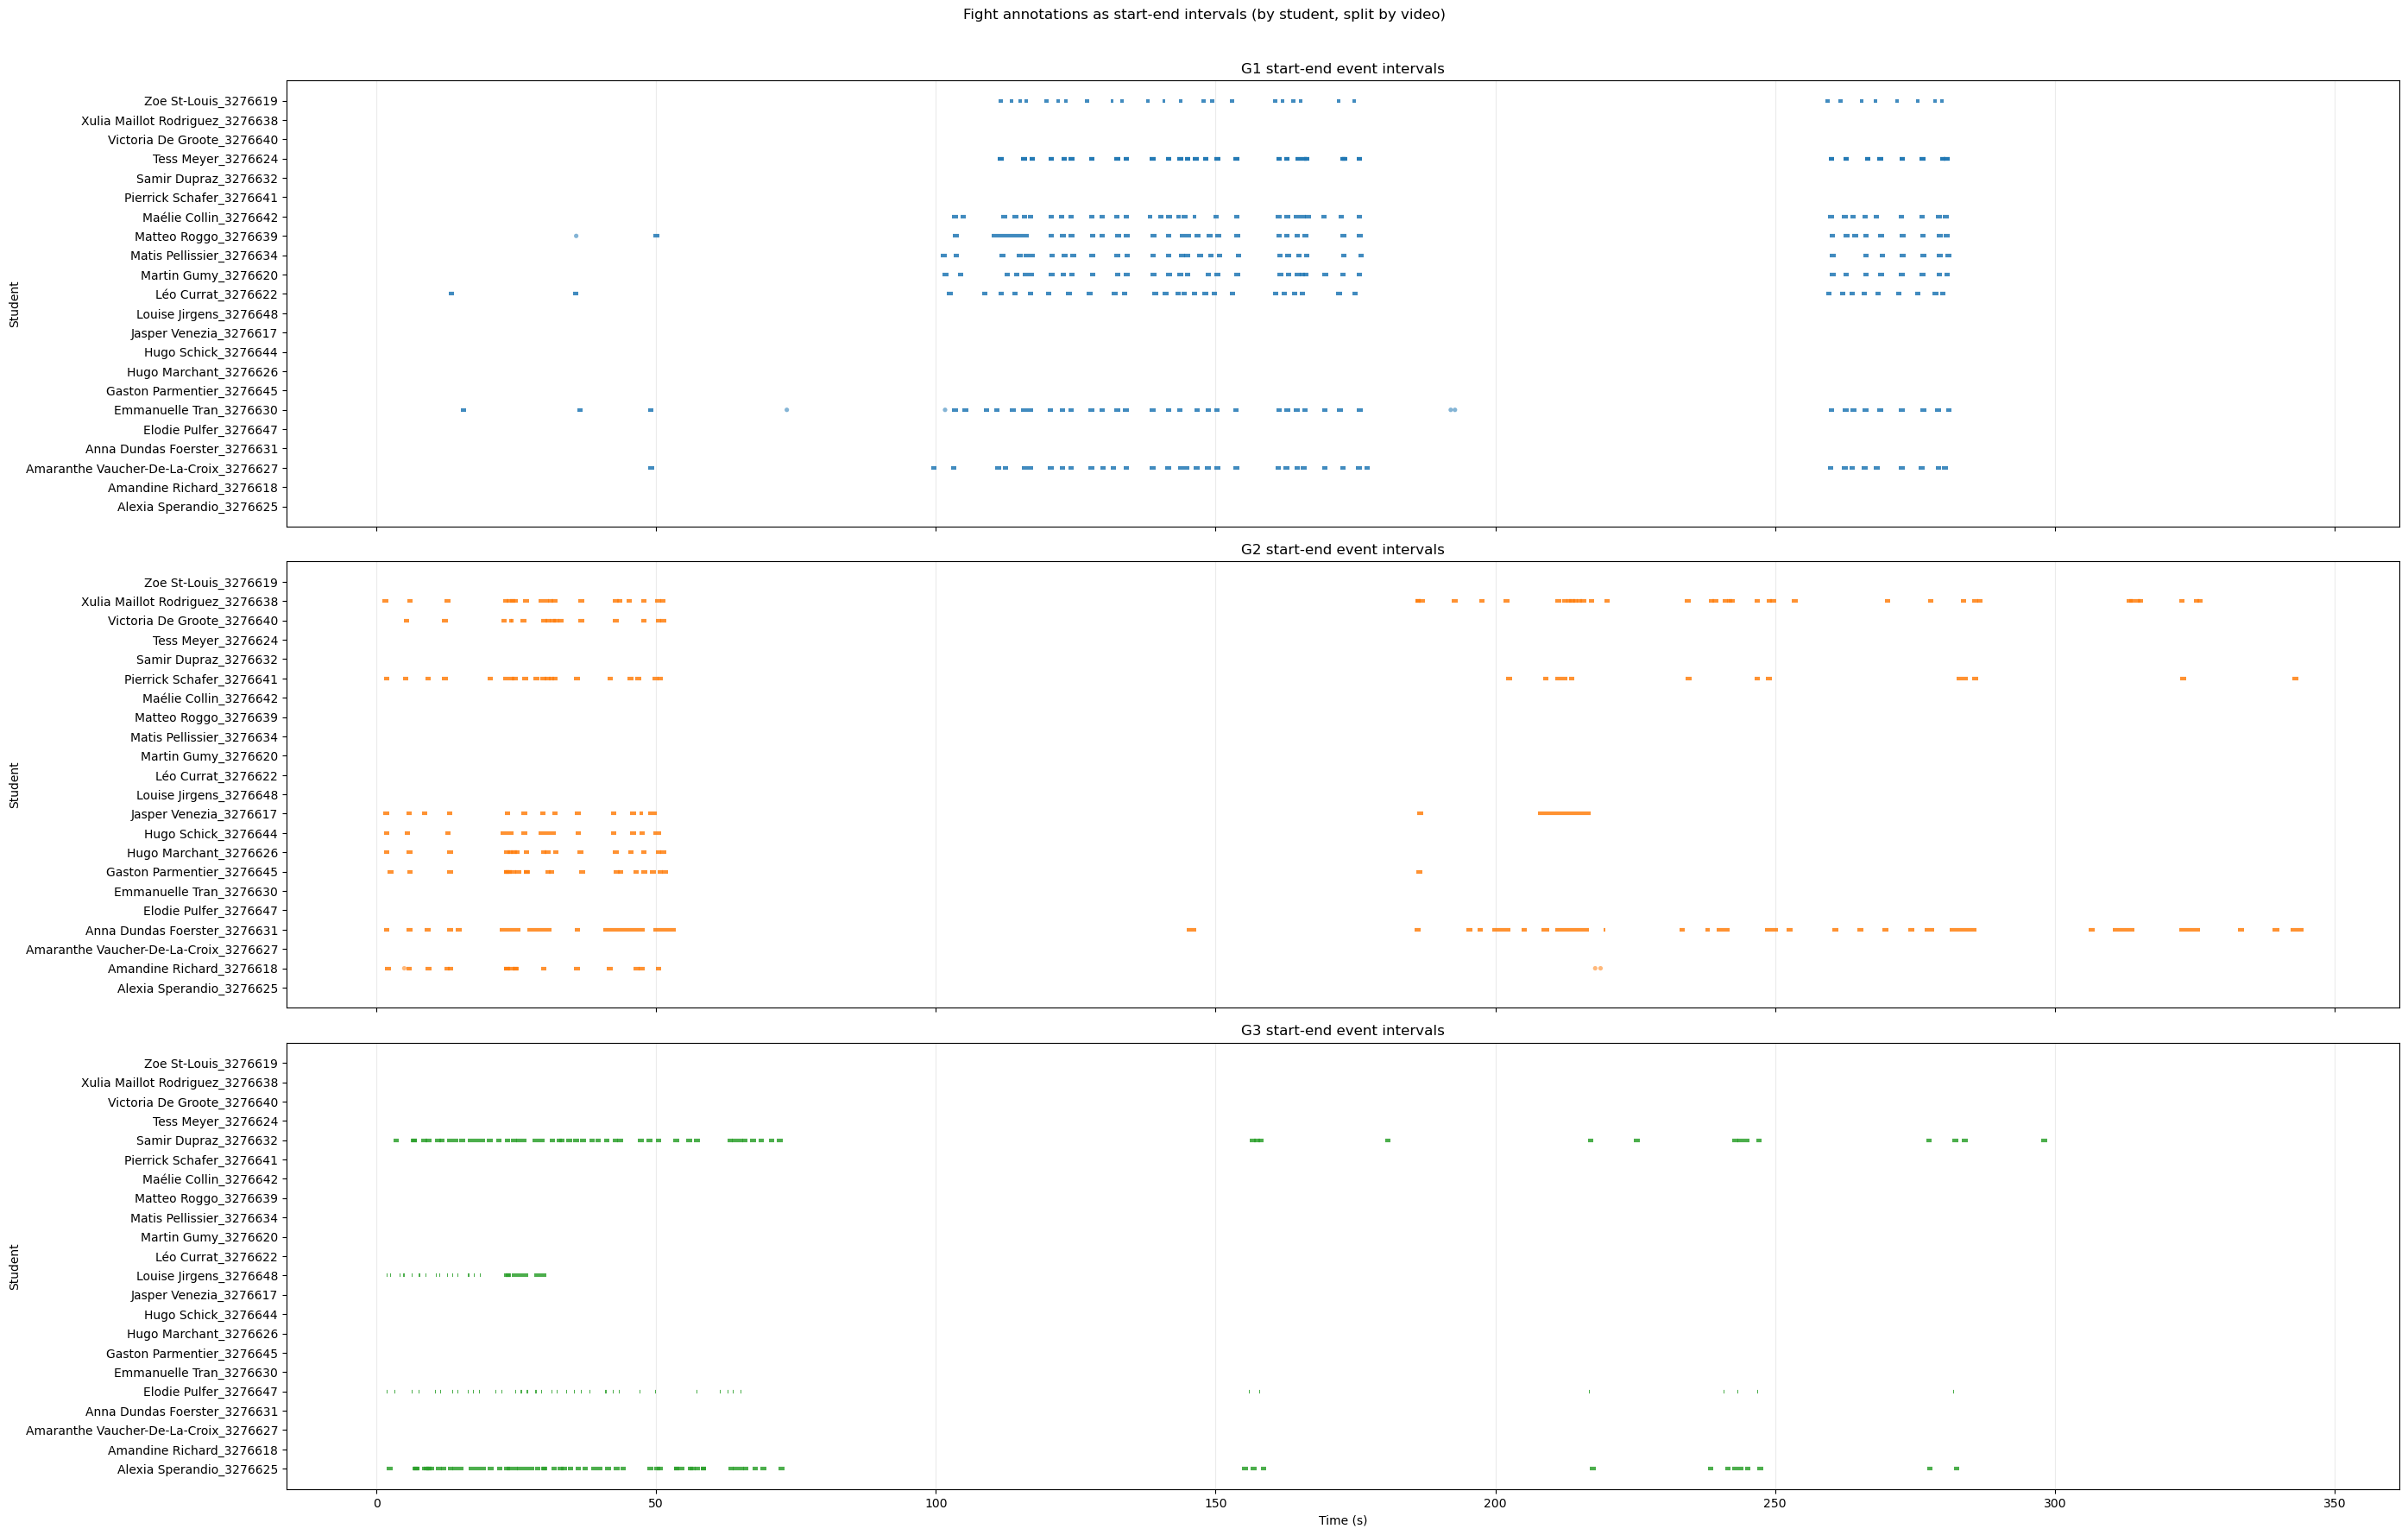

In [15]:
# Plot event intervals explicitly (start -> end) for each student and video
import matplotlib.pyplot as plt

# Reuse tidy table when available; fallback to clean_events_df
if "tidy_events_df" in globals() and isinstance(tidy_events_df, pd.DataFrame) and not tidy_events_df.empty:
    interval_plot_df = tidy_events_df.copy()
elif "clean_events_df" in globals() and isinstance(clean_events_df, pd.DataFrame) and not clean_events_df.empty:
    interval_plot_df = clean_events_df.copy()
else:
    interval_plot_df = pd.DataFrame()

if interval_plot_df.empty:
    print("No parsed events available. Run parsing cells first.")
else:
    interval_plot_df = interval_plot_df[interval_plot_df["video_id"].isin(["g1", "g2", "g3"])].copy()

    for col in ["time_start", "time_end", "time_point"]:
        if col in interval_plot_df.columns:
            interval_plot_df[col] = pd.to_numeric(interval_plot_df[col], errors="coerce")

    users = sorted(interval_plot_df["user"].dropna().unique().tolist())
    if len(users) == 0:
        print("No valid user rows to plot.")
    else:
        user_to_y = {u: i for i, u in enumerate(users)}
        video_ids = ["g1", "g2", "g3"]
        colors = {"g1": "#1f77b4", "g2": "#ff7f0e", "g3": "#2ca02c"}

        fig, axes = plt.subplots(
            3, 1,
            figsize=(28, max(10, 0.45 * len(users) * 1.8)),
            sharex=True,
            sharey=True,
        )

        for ax, vid in zip(axes, video_ids):
            vdf = interval_plot_df[interval_plot_df["video_id"] == vid].copy()

            # Primary view: true interval events with start and end
            seg = vdf.dropna(subset=["time_start", "time_end"]).copy()
            for _, row in seg.iterrows():
                y = user_to_y.get(row["user"])
                if y is None:
                    continue
                t0, t1 = float(row["time_start"]), float(row["time_end"])
                if t1 < t0:
                    t0, t1 = t1, t0
                ax.hlines(
                    y=y,
                    xmin=t0,
                    xmax=t1,
                    color=colors[vid],
                    linewidth=3,
                    alpha=0.85,
                )

            # Optional fallback: events without end-time as point markers
            pts = vdf[
                vdf["time_start"].isna()
                & vdf["time_end"].isna()
                & vdf["time_point"].notna()
            ].copy()
            if not pts.empty:
                ax.scatter(
                    pts["time_point"],
                    pts["user"].map(user_to_y),
                    s=14,
                    color=colors[vid],
                    alpha=0.55,
                    edgecolor="none",
                )

            ax.set_title(f"{vid.upper()} start-end event intervals")
            ax.grid(axis="x", alpha=0.25)

        for ax in axes:
            ax.set_yticks(range(len(users)))
            ax.set_yticklabels(users)
            ax.set_ylabel("Student")

        axes[-1].set_xlabel("Time (s)")
        fig.suptitle("Fight annotations as start-end intervals (by student, split by video)", y=0.995)
        fig.tight_layout(rect=[0, 0, 1, 0.985])
        plt.show()